Saving WineQT.csv to WineQT.csv
Dataset Shape: (1143, 13)
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


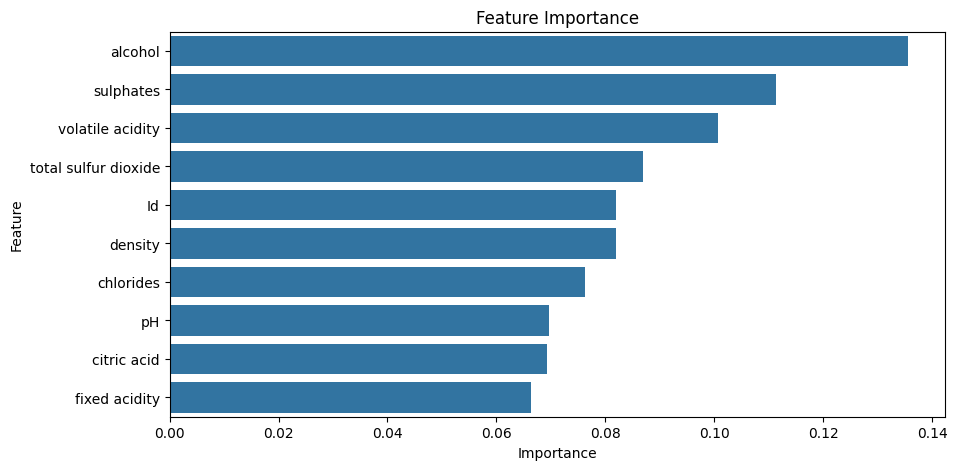

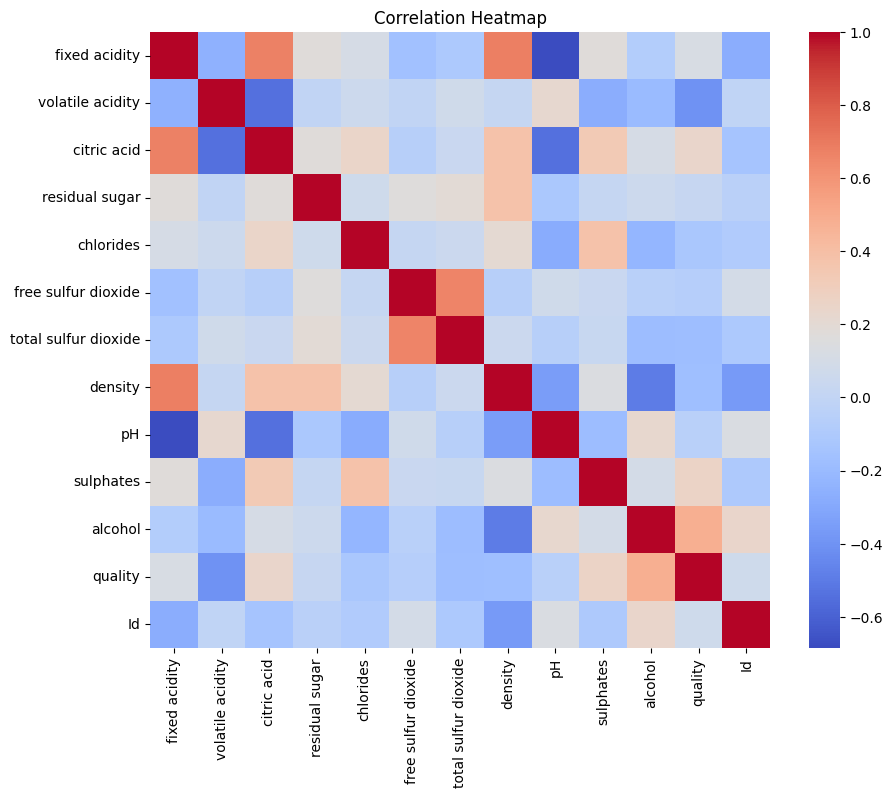

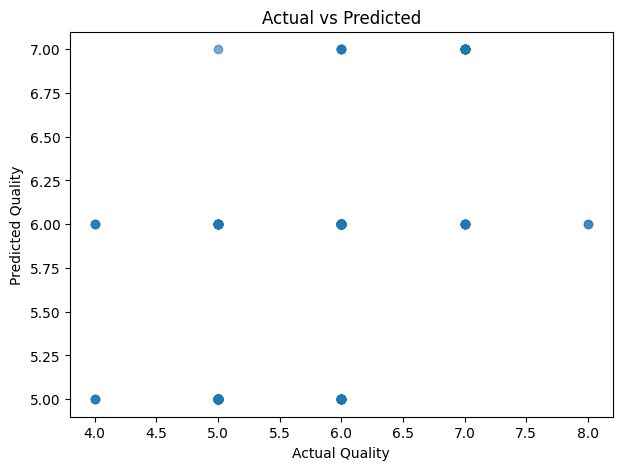


Project Completed Successfully
Output File Saved


In [ ]:

# WINE QUALITY PREDICTION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

# Upload Dataset
uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Dataset Shape:", df.shape)
print(df.head())

# CHECK MISSING VALUES

print("\nMissing Values")
print(df.isnull().sum())

# FEATURES & TARGET

X = df.drop(['quality'], axis=1)
y = df['quality']

# TRAIN TEST SPLIT

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# --------------------------------
# RANDOM FOREST MODEL
# --------------------------------

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

# ACCURACY

acc = accuracy_score(y_test, pred)

print("\nAccuracy:", round(acc*100,2), "%")

print("\nClassification Report")
print(classification_report(y_test, pred))

# FEATURE IMPORTANCE

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop Features")
print(importance.head(10))

# FEATURE IMPORTANCE GRAPH

plt.figure(figsize=(10,5))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

# CORRELATION HEATMAP

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# ACTUAL VS PREDICTED

plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    pred,
    alpha=0.6
)

plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Actual vs Predicted")
plt.show()

# SAVE OUTPUT


output = pd.DataFrame({
    "Actual": y_test,
    "Predicted": pred
})

output.to_csv(
    "wine_quality_predictions.csv",
    index=False
)

print("\nProject Completed Successfully")
print("Output File Saved")